# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH TỪ TẬP DATA ĐÃ CHIA

Notebook này chỉ tập trung vào việc Train Model dựa trên Output của Notebook trước.


In [1]:
!pip install -q scikit-learn pandas tf-keras


In [2]:
import json
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, fbeta_score, precision_recall_fscore_support


2026-05-22 09:02:17.319413: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779440537.548404      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779440537.617125      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779440538.158901      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779440538.158939      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779440538.158942      57 computation_placer.cc:177] computation placer alr

## 2. Cấu hình hệ thống (Config)


In [3]:
class config:
    """Central configuration for ver2 fall-detection pipeline."""
    
    ROOT = Path("/kaggle/working")
    # ĐƯỜNG DẪN TỚI THƯ MỤC SPLITS CỦA NOTEBOOK TRƯỚC (THAY ĐỔI DÒNG DƯỚI NẾU CẦN)
    DATA_SPLITS = Path("/kaggle/input/kaggle-full-pipeline/data/splits")
    
    # Data layout
    
    
    MANIFEST_PATH = ROOT / "data" / "video_split_manifest.csv"
    SPLIT_STATS_PATH = ROOT / "data" / "split_stats.json"
    
    # Training artifacts
    ARTIFACTS_DIR = ROOT / "artifacts"
    REPORT_DIR = ROOT / "report"
    
    # Sequence / features (must match deploy/app.py)
    INPUT_TIMESTEPS = 30
    NUM_KEYPOINTS = 17
    NUM_FEATURES = NUM_KEYPOINTS * 3  # x, y, visibility
    
    KEYPOINT_NAMES = [
        "Nose", "Left Eye", "Right Eye", "Left Ear", "Right Ear",
        "Left Shoulder", "Right Shoulder", "Left Elbow", "Right Elbow",
        "Left Wrist", "Right Wrist", "Left Hip", "Right Hip",
        "Left Knee", "Right Knee", "Left Ankle", "Right Ankle",
    ]
    SORTED_KEYPOINT_NAMES = sorted(KEYPOINT_NAMES)
    KEYPOINT_DICT = {name: i for i, name in enumerate(SORTED_KEYPOINT_NAMES)}
    
    MIN_KEYPOINT_CONFIDENCE = 0.3
    
    # Train/val/test ratios (video-level)
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    SPLIT_RANDOM_STATE = 42
    
    # Transformer hyperparameters
    NUM_ENCODER_BLOCKS = 3
    D_MODEL = 64
    NUM_HEADS = 4
    FF_DIM = D_MODEL * 2
    PROJECTION_DIM = D_MODEL
    FINAL_DENSE_UNITS = 32
    DROPOUT_RATE = 0.1
    LEARNING_RATE = 5e-4
    
    # LSTM baseline
    LSTM_UNITS = 64
    LSTM_DROPOUT = 0.2
    
    # Training
    BATCH_SIZE = 32
    EPOCHS = 60
    EARLY_STOPPING_PATIENCE = 15
    
    # Inference / deployment
    DEFAULT_THRESHOLD = 0.5
    TFLITE_MODEL_NAME = "fall_detection_transformer.tflite"
    SAVED_MODEL_DIR = "fall_model_exported_sm"
    


## 3. Khai báo các Hàm (Keypoints, Skeleton, Dataloader, Model, Metrics)


In [4]:
"""Keypoint indexing consistent with training and TFLite deployment."""
from __future__ import annotations



def get_kpt_indices(keypoint_name: str) -> tuple[int, int, int]:
    if keypoint_name not in config.KEYPOINT_DICT:
        raise ValueError(
            f"Keypoint '{keypoint_name}' not in KEYPOINT_DICT. "
            f"Available: {list(config.KEYPOINT_DICT.keys())}"
        )
    kp_idx = config.KEYPOINT_DICT[keypoint_name]
    return kp_idx * 3, kp_idx * 3 + 1, kp_idx * 3 + 2



In [5]:
"""Skeleton normalization (hip-centered, shoulder-hip scale)."""
from __future__ import annotations

import numpy as np



def normalize_skeleton_frame(
    frame_features: np.ndarray,
    min_confidence: float = config.MIN_KEYPOINT_CONFIDENCE,
) -> np.ndarray:
    normalized = np.copy(frame_features)
    refs = {
        "ls": "Left Shoulder",
        "rs": "Right Shoulder",
        "lh": "Left Hip",
        "rh": "Right Hip",
    }
    try:
        ls_x_i, ls_y_i, ls_c_i = get_kpt_indices(refs["ls"])
        rs_x_i, rs_y_i, rs_c_i = get_kpt_indices(refs["rs"])
        lh_x_i, lh_y_i, lh_c_i = get_kpt_indices(refs["lh"])
        rh_x_i, rh_y_i, rh_c_i = get_kpt_indices(refs["rh"])
    except ValueError:
        return frame_features

    ls_x, ls_y, ls_c = frame_features[ls_x_i], frame_features[ls_y_i], frame_features[ls_c_i]
    rs_x, rs_y, rs_c = frame_features[rs_x_i], frame_features[rs_y_i], frame_features[rs_c_i]
    lh_x, lh_y, lh_c = frame_features[lh_x_i], frame_features[lh_y_i], frame_features[lh_c_i]
    rh_x, rh_y, rh_c = frame_features[rh_x_i], frame_features[rh_y_i], frame_features[rh_c_i]

    mid_shoulder_x, mid_shoulder_y = np.nan, np.nan
    if ls_c > min_confidence and rs_c > min_confidence:
        mid_shoulder_x, mid_shoulder_y = (ls_x + rs_x) / 2, (ls_y + rs_y) / 2
    elif ls_c > min_confidence:
        mid_shoulder_x, mid_shoulder_y = ls_x, ls_y
    elif rs_c > min_confidence:
        mid_shoulder_x, mid_shoulder_y = rs_x, rs_y

    mid_hip_x, mid_hip_y = np.nan, np.nan
    if lh_c > min_confidence and rh_c > min_confidence:
        mid_hip_x, mid_hip_y = (lh_x + rh_x) / 2, (lh_y + rh_y) / 2
    elif lh_c > min_confidence:
        mid_hip_x, mid_hip_y = lh_x, lh_y
    elif rh_c > min_confidence:
        mid_hip_x, mid_hip_y = rh_x, rh_y

    if np.isnan(mid_hip_x) or np.isnan(mid_hip_y):
        return frame_features

    reference_height = np.nan
    if not np.isnan(mid_shoulder_y) and not np.isnan(mid_hip_y):
        reference_height = abs(mid_shoulder_y - mid_hip_y)

    perform_scaling = not (np.isnan(reference_height) or reference_height < 1e-5)

    for kp_name in config.SORTED_KEYPOINT_NAMES:
        try:
            x_i, y_i, _ = get_kpt_indices(kp_name)
            normalized[x_i] -= mid_hip_x
            normalized[y_i] -= mid_hip_y
            if perform_scaling:
                normalized[x_i] /= reference_height
                normalized[y_i] /= reference_height
        except ValueError:
            pass
    return normalized


def normalize_skeleton(
    sequence: np.ndarray,
    min_confidence: float = config.MIN_KEYPOINT_CONFIDENCE,
) -> np.ndarray:
    out = np.copy(sequence)
    for t in range(sequence.shape[0]):
        out[t] = normalize_skeleton_frame(sequence[t], min_confidence=min_confidence)
    return out



In [6]:
"""Load .npy skeleton sequences from split folders."""
from __future__ import annotations

import os
from glob import glob
from pathlib import Path

import numpy as np



def expected_shape() -> tuple[int, int]:
    return config.INPUT_TIMESTEPS, config.NUM_FEATURES


def load_dataset(
    data_path: str | Path,
    normalize: bool = True,
    min_confidence: float = config.MIN_KEYPOINT_CONFIDENCE,
) -> tuple[np.ndarray, np.ndarray, list[str]]:
    data_path = Path(data_path)
    exp_shape = expected_shape()
    x_list: list[np.ndarray] = []
    y_list: list[int] = []
    paths: list[str] = []

    print(f"Loading from {data_path}, expected shape {exp_shape}")
    for label_name, label_val in [("no_fall", 0), ("fall", 1)]:
        folder = data_path / label_name
        if not folder.is_dir():
            print(f"  Warning: missing folder {folder}")
            continue
        files = sorted(glob(str(folder / "*.npy")))
        loaded = 0
        for fp in files:
            try:
                arr = np.load(fp)
            except Exception as e:
                print(f"  Warning: cannot load {fp}: {e}")
                continue
            if arr.shape != exp_shape:
                print(f"  Warning: skip {fp} shape {arr.shape} != {exp_shape}")
                continue
            if normalize:
                arr = normalize_skeleton(arr, min_confidence=min_confidence)
                if np.isnan(arr).any():
                    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
            x_list.append(arr.astype(np.float32))
            y_list.append(label_val)
            paths.append(fp)
            loaded += 1
        print(f"  {label_name}: {loaded}/{len(files)} sequences")

    if not x_list:
        return np.array([]), np.array([]), []
    return np.stack(x_list), np.array(y_list, dtype=np.float32), paths



In [7]:
"""LSTM baseline for skeleton sequences."""
from __future__ import annotations

import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam



def create_lstm_classifier(
    input_shape: tuple[int, int] | None = None,
    lstm_units: int = config.LSTM_UNITS,
    dropout_rate: float = config.LSTM_DROPOUT,
    learning_rate: float = config.LEARNING_RATE,
) -> tf.keras.Model:
    if input_shape is None:
        input_shape = (config.INPUT_TIMESTEPS, config.NUM_FEATURES)

    f1_macro = tf.keras.metrics.F1Score(
        average="macro",
        threshold=0.5,
        name="f1_macro",
    )
    model = Sequential(name="lstm_fall_classifier")
    model.add(LSTM(lstm_units, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(lstm_units // 2))
    model.add(Dropout(dropout_rate))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", f1_macro],
    )
    return model



In [8]:
"""Transformer classifier for skeleton sequences."""
from __future__ import annotations

import tensorflow as tf
from tensorflow.keras.layers import (
    Add,
    Dense,
    Dropout,
    Embedding,
    GlobalAveragePooling1D,
    Input,
    LayerNormalization,
    MultiHeadAttention,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam



def transformer_encoder_block(
    inputs,
    d_model: int,
    num_heads: int,
    ff_dim: int,
    dropout_rate: float = 0.1,
    name_prefix: str = "",
):
    attn = MultiHeadAttention(
        num_heads=num_heads,
        key_dim=d_model // num_heads,
        dropout=dropout_rate,
        name=f"{name_prefix}_mha",
    )(inputs, inputs, inputs)
    attn = Dropout(dropout_rate, name=f"{name_prefix}_mha_dropout")(attn)
    out1 = LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_layernorm1")(inputs + attn)

    ffn = Dense(ff_dim, activation="relu", name=f"{name_prefix}_ffn_dense1")(out1)
    ffn = Dense(d_model, name=f"{name_prefix}_ffn_dense2")(ffn)
    ffn = Dropout(dropout_rate, name=f"{name_prefix}_ffn_dropout")(ffn)
    out2 = LayerNormalization(epsilon=1e-6, name=f"{name_prefix}_layernorm2")(out1 + ffn)
    return out2


def positional_embedding(seq_len: int, d_model: int, name_prefix: str = ""):
    positions = tf.range(start=0, limit=seq_len, delta=1)
    pos_2d = Embedding(
        input_dim=seq_len,
        output_dim=d_model,
        name=f"{name_prefix}_pos_embed",
    )(positions)
    return tf.expand_dims(pos_2d, axis=0)


def create_transformer_classifier(
    input_shape: tuple[int, int] | None = None,
    num_encoder_blocks: int = config.NUM_ENCODER_BLOCKS,
    d_model: int = config.D_MODEL,
    num_heads: int = config.NUM_HEADS,
    ff_dim: int = config.FF_DIM,
    projection_dim: int | None = None,
    final_dense_units: int = config.FINAL_DENSE_UNITS,
    dropout_rate: float = config.DROPOUT_RATE,
    learning_rate: float = config.LEARNING_RATE,
) -> Model:
    if input_shape is None:
        input_shape = (config.INPUT_TIMESTEPS, config.NUM_FEATURES)
    if projection_dim is None:
        projection_dim = d_model

    timesteps, _ = input_shape
    inputs = Input(shape=input_shape, name="input_features")
    x = Dense(projection_dim, name="feature_projection")(inputs)
    pos = positional_embedding(timesteps, projection_dim, name_prefix="pos_enc")
    x = Add(name="add_positional_encoding")([x, pos])
    x = Dropout(dropout_rate, name="input_dropout_after_pos_enc")(x)

    for i in range(num_encoder_blocks):
        x = transformer_encoder_block(
            x,
            projection_dim,
            num_heads,
            ff_dim,
            dropout_rate,
            name_prefix=f"encoder_block_{i + 1}",
        )

    x = GlobalAveragePooling1D(name="global_avg_pooling")(x)
    x = Dropout(dropout_rate, name="dropout_after_pooling")(x)
    x = Dense(final_dense_units, activation="relu", name="final_dense_1")(x)
    x = Dropout(dropout_rate / 2, name="dropout_final_dense")(x)
    outputs = Dense(1, activation="sigmoid", name="output_sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs)
    f1_macro = tf.keras.metrics.F1Score(
        average="macro",
        threshold=0.5,
        name="f1_macro",
    )
    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy", f1_macro],
    )
    return model



In [9]:
"""Evaluation metrics and threshold tuning."""
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    fbeta_score,
    precision_recall_fscore_support,
)


@dataclass
class EvalResult:
    threshold: float
    accuracy: float
    precision_fall: float
    recall_fall: float
    f1_fall: float
    f2_fall: float
    confusion: np.ndarray
    report: str


def predict_labels(probs: np.ndarray, threshold: float) -> np.ndarray:
    return (probs.reshape(-1) >= threshold).astype(int)


def evaluate_at_threshold(
    y_true: np.ndarray,
    probs: np.ndarray,
    threshold: float,
) -> EvalResult:
    y_pred = predict_labels(probs, threshold)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average="binary", zero_division=0
    )
    f2 = fbeta_score(y_true, y_pred, beta=2, pos_label=1, zero_division=0)
    report = classification_report(
        y_true, y_pred, target_names=["no_fall", "fall"], zero_division=0
    )
    return EvalResult(
        threshold=threshold,
        accuracy=float(accuracy_score(y_true, y_pred)),
        precision_fall=float(prec),
        recall_fall=float(rec),
        f1_fall=float(f1),
        f2_fall=float(f2),
        confusion=cm,
        report=report,
    )


def find_best_threshold(
    y_true: np.ndarray,
    probs: np.ndarray,
    metric: str = "f2_fall",
    thresholds: np.ndarray | None = None,
) -> EvalResult:
    if thresholds is None:
        thresholds = np.arange(0.1, 0.91, 0.01)
    best: EvalResult | None = None
    for t in thresholds:
        result = evaluate_at_threshold(y_true, probs, float(t))
        score = getattr(result, metric)
        if best is None or score > getattr(best, metric):
            best = result
    assert best is not None
    return best


def error_analysis_df(
    y_true: np.ndarray,
    probs: np.ndarray,
    filepaths: list[str],
    threshold: float,
    split_name: str,
) -> pd.DataFrame:
    y_pred = predict_labels(probs, threshold)
    rows = []
    for i, fp in enumerate(filepaths):
        true_l = "fall" if y_true[i] == 1 else "no_fall"
        pred_l = "fall" if y_pred[i] == 1 else "no_fall"
        err_type = "TP" if y_true[i] == 1 and y_pred[i] == 1 else ""
        if y_true[i] == 0 and y_pred[i] == 1:
            err_type = "FP"
        elif y_true[i] == 1 and y_pred[i] == 0:
            err_type = "FN"
        elif y_true[i] == 0 and y_pred[i] == 0:
            err_type = "TN"
        rows.append(
            {
                "File Name": Path(fp).name,
                "True": true_l,
                "Pred": pred_l,
                "Prob": float(probs.reshape(-1)[i]),
                "Type": err_type,
                "Set": split_name,
            }
        )
    return pd.DataFrame(rows)


def metrics_summary_row(model_name: str, split_name: str, result: EvalResult) -> dict:
    return {
        "Model": model_name,
        "Split": split_name,
        "Threshold": result.threshold,
        "Accuracy": result.accuracy,
        "Precision_fall": result.precision_fall,
        "Recall_fall": result.recall_fall,
        "F1_fall": result.f1_fall,
        "F2_fall": result.f2_fall,
    }



In [10]:
"""Export Keras model to TFLite."""
from __future__ import annotations

from pathlib import Path

import tensorflow as tf



def export_to_tflite(
    model: tf.keras.Model,
    export_dir: Path | None = None,
    tflite_path: Path | None = None,
) -> Path:
    export_dir = export_dir or (config.ARTIFACTS_DIR / config.SAVED_MODEL_DIR)
    tflite_path = tflite_path or (config.ARTIFACTS_DIR / config.TFLITE_MODEL_NAME)

    export_dir = Path(export_dir)
    tflite_path = Path(tflite_path)
    export_dir.mkdir(parents=True, exist_ok=True)
    tflite_path.parent.mkdir(parents=True, exist_ok=True)

    model.export(str(export_dir))
    converter = tf.lite.TFLiteConverter.from_saved_model(str(export_dir))
    tflite_bytes = converter.convert()
    tflite_path.write_bytes(tflite_bytes)
    size_kb = len(tflite_bytes) / 1024
    print(f"Saved TFLite: {tflite_path} ({size_kb:.2f} KB)")
    return tflite_path


def verify_tflite(tflite_path: Path) -> dict:
    interp = tf.lite.Interpreter(model_path=str(tflite_path))
    interp.allocate_tensors()
    inp = interp.get_input_details()[0]
    out = interp.get_output_details()[0]
    info = {
        "input_shape": inp["shape"],
        "input_dtype": str(inp["dtype"]),
        "output_shape": out["shape"],
        "output_dtype": str(out["dtype"]),
    }
    expected = [1, config.INPUT_TIMESTEPS, config.NUM_FEATURES]
    if list(inp["shape"]) != expected:
        raise ValueError(f"TFLite input {inp['shape']} != expected {expected}")
    return info



In [11]:
def train_model(
    model: tf.keras.Model,
    x_train: np.ndarray,
    y_train: np.ndarray,
    x_val: np.ndarray,
    y_val: np.ndarray,
    model_tag: str,
    epochs: int,
    batch_size: int,
) -> tf.keras.Model:
    callbacks = [
        EarlyStopping(
            monitor="val_f1_macro",
            patience=config.EARLY_STOPPING_PATIENCE,
            mode="max",
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_f1_macro",
            factor=0.5,
            patience=5,
            mode="max",
            min_lr=1e-6,
            verbose=1,
        ),
    ]
    y_train_2d = y_train.reshape(-1, 1)
    y_val_2d = y_val.reshape(-1, 1)
    history = model.fit(
        x_train,
        y_train_2d,
        validation_data=(x_val, y_val_2d),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )
    hist_path = config.ARTIFACTS_DIR / f"{model_tag}_history.json"
    hist_path.parent.mkdir(parents=True, exist_ok=True)
    serializable = {k: [float(v) for v in vals] for k, vals in history.history.items()}
    hist_path.write_text(json.dumps(serializable, indent=2), encoding="utf-8")
    return model


## 4. CHẠY HUẤN LUYỆN (EXECUTION)


In [12]:

import os
config.ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
config.REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Tự động dò tìm đường dẫn thực tế của thư mục splits trong /kaggle/input
found_splits = None
input_base = Path("/kaggle/input")
if input_base.exists():
    for root, dirs, files in os.walk(input_base):
        # Nếu thư mục hiện tại tên là splits và bên trong có thư mục train
        if Path(root).name == "splits" and "train" in dirs:
            found_splits = Path(root)
            break

if found_splits:
    config.DATA_SPLITS = found_splits
    print(f"Đã TỰ ĐỘNG tìm thấy dữ liệu tại: {config.DATA_SPLITS}")
else:
    print(f"Đang đọc dữ liệu mặc định từ: {config.DATA_SPLITS}")

if not config.DATA_SPLITS.exists():
    print(f"\nLỖI: Không tìm thấy thư mục {config.DATA_SPLITS}!")
    print("Vui lòng click 'Add Input' trên Kaggle, chọn Notebook cũ của bạn, sau đó copy đường dẫn của thư mục data/splits paste vào biến DATA_SPLITS ở phần Config phía trên.")
else:
    # Load dataset
    x_train, y_train, _ = load_dataset(config.DATA_SPLITS / "train")
    x_val, y_val, _ = load_dataset(config.DATA_SPLITS / "val")
    x_test, y_test, test_paths = load_dataset(config.DATA_SPLITS / "test")

    print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

    # Chọn 'lstm' hoặc 'transformer'
    MODEL_TYPE = 'transformer'

    if MODEL_TYPE == "lstm":
        model = create_lstm_classifier()
        model_tag = "lstm"
    else:
        model = create_transformer_classifier()
        model_tag = "transformer"
        
    keras_path = config.ARTIFACTS_DIR / f"{model_tag}_best.keras"
    model = train_model(model, x_train, y_train, x_val, y_val, model_tag, config.EPOCHS, config.BATCH_SIZE)
    model.save(keras_path)

    val_probs = model.predict(x_val, verbose=0).reshape(-1)
    best_val = find_best_threshold(y_val, val_probs, metric="f2_fall")
    print(f"\nNgưỡng tốt nhất trên VAL: {best_val.threshold:.2f}")
    print(best_val.report)

    if len(x_test) > 0:
        test_probs = model.predict(x_test, verbose=0).reshape(-1)
        test_res = evaluate_at_threshold(y_test, test_probs, best_val.threshold)
        print(f"\nKẾT QUẢ TEST @ threshold {best_val.threshold:.2f}:")
        print(test_res.report)

    if MODEL_TYPE == "transformer":
        tflite_path = export_to_tflite(model)
        verify_tflite(tflite_path)
        print(f"TFLite exported successfully to: {tflite_path}")



Đã TỰ ĐỘNG tìm thấy dữ liệu tại: /kaggle/input/notebooks/anhoa1/kaggle-full-pipeline/data/splits
Loading from /kaggle/input/notebooks/anhoa1/kaggle-full-pipeline/data/splits/train, expected shape (30, 51)
  no_fall: 14727/14727 sequences
  fall: 8631/8631 sequences
Loading from /kaggle/input/notebooks/anhoa1/kaggle-full-pipeline/data/splits/val, expected shape (30, 51)
  no_fall: 3024/3024 sequences
  fall: 1821/1821 sequences
Loading from /kaggle/input/notebooks/anhoa1/kaggle-full-pipeline/data/splits/test, expected shape (30, 51)
  no_fall: 3040/3040 sequences
  fall: 1921/1921 sequences
Train: (23358, 30, 51), Val: (4845, 30, 51), Test: (4961, 30, 51)


I0000 00:00:1779440919.552247      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779440919.558181      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Epoch 1/60


I0000 00:00:1779440930.363457     146 service.cc:152] XLA service 0x7fd30c0041e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779440930.363522     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779440930.363528     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779440931.950839     146 cuda_dnn.cc:529] Loaded cuDNN version 91002


 24/730 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6088 - f1_macro: 0.2169 - loss: 0.6784       

I0000 00:00:1779440941.098640     146 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


730/730 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.6874 - f1_macro: 0.5001 - loss: 0.5945 - val_accuracy: 0.7496 - val_f1_macro: 0.6050 - val_loss: 0.5329 - learning_rate: 5.0000e-04
Epoch 2/60
730/730 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7432 - f1_macro: 0.6176 - loss: 0.5278 - val_accuracy: 0.7742 - val_f1_macro: 0.6746 - val_loss: 0.4929 - learning_rate: 5.0000e-04
Epoch 3/60
730/730 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7628 - f1_macro: 0.6515 - loss: 0.4980 - val_accuracy: 0.7858 - val_f1_macro: 0.6909 - val_loss: 0.4946 - learning_rate: 5.0000e-04
Epoch 4/60
730/730 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7836 - f1_macro: 0.6800 - loss: 0.4707 - val_accuracy: 0.7835 - val_f1_macro: 0.6925 - val_loss: 0.4874 - learning_rate: 5.0000e-04
Epoch 5/60
730/730 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7972 - f1_macro: 0.6993 - loss: 0.4530 - val_accuracy: 0.7971 - val_f1_macro: 0.6976 - val_loss: 0.4594 - learning_rate: 5.0000e-04
Epoch 6/60
730/730 

INFO:tensorflow:Assets written to: /kaggle/working/artifacts/fall_model_exported_sm/assets


Saved artifact at '/kaggle/working/artifacts/fall_model_exported_sm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 51), dtype=tf.float32, name='input_features')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  140548146200016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137484944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137488592: TensorSpec(shape=(1, 30, 64), dtype=tf.float32, name=None)
  140548137488784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137485712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137489360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137488208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137487824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137490512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140548137490320: TensorSpec(shape=(), dtype=tf.

W0000 00:00:1779441250.206113      57 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1779441250.206177      57 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1779441250.236371      57 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [13]:
# Tải tập test đã chia sẵn trên Kaggle
x_test, y_test, test_paths = load_dataset(config.DATA_SPLITS / "test")

if len(x_test) > 0:
    # Cho model dự đoán trên tập test
    test_probs = model.predict(x_test, verbose=1).reshape(-1)
    
    # Tính toán các metric dựa trên hàm evaluate_at_threshold đã viết sẵn
    # (Sử dụng ngưỡng best_val.threshold nếu bạn vẫn giữ biến đó trên Kaggle, hoặc lấy mặc định 0.5)
    threshold = 0.5 
    
    test_res = evaluate_at_threshold(y_test, test_probs, threshold)
    
    print(f"\n=== KẾT QUẢ CLASSIFICATION REPORT (PRECISION, RECALL, F1) ===")
    print(test_res.report)
    
    print("\n=== CONFUSION MATRIX ===")
    print(test_res.confusion)
else:
    print("Không tìm thấy dữ liệu test. Vui lòng kiểm tra lại đường dẫn config.DATA_SPLITS")

Loading from /kaggle/input/notebooks/anhoa1/kaggle-full-pipeline/data/splits/test, expected shape (30, 51)
  no_fall: 3040/3040 sequences
  fall: 1921/1921 sequences
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

=== KẾT QUẢ CLASSIFICATION REPORT (PRECISION, RECALL, F1) ===
              precision    recall  f1-score   support

     no_fall       0.83      0.89      0.86      3040
        fall       0.81      0.72      0.76      1921

    accuracy                           0.83      4961
   macro avg       0.82      0.81      0.81      4961
weighted avg       0.82      0.83      0.82      4961


=== CONFUSION MATRIX ===
[[2716  324]
 [ 542 1379]]


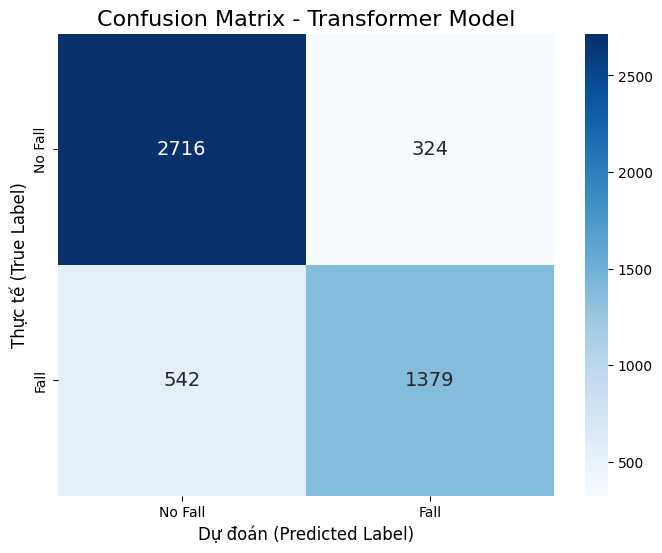

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Vẽ Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(test_res.confusion, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Fall', 'Fall'], 
            yticklabels=['No Fall', 'Fall'],
            annot_kws={"size": 14}) # Phóng to chữ số bên trong

plt.title('Confusion Matrix - Transformer Model', fontsize=16)
plt.ylabel('Thực tế (True Label)', fontsize=12)
plt.xlabel('Dự đoán (Predicted Label)', fontsize=12)

# Hiển thị hình vẽ
plt.show()

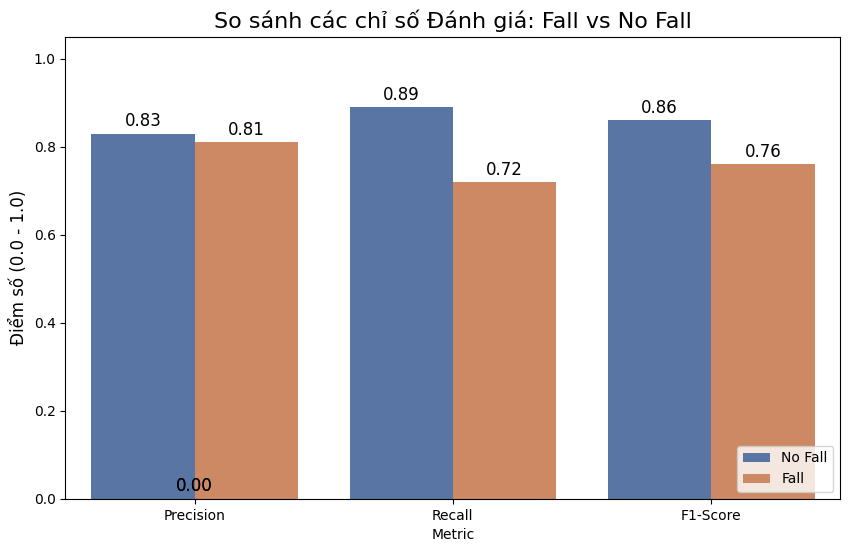

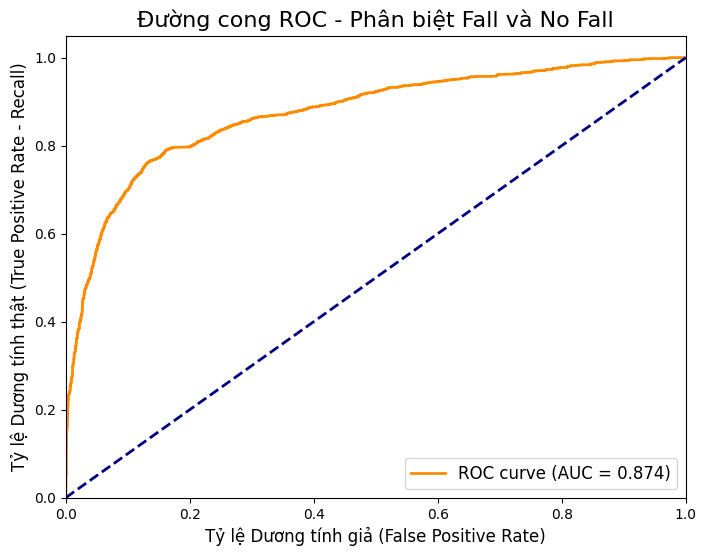

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc

# --- 1. BIỂU ĐỒ CỘT SO SÁNH PRECISION, RECALL, F1 ---
# Trích xuất dữ liệu từ test_res (đã chạy ở ô trước)
report_dict = test_res.report  # Nếu hàm trả về string, ta lấy dữ liệu tĩnh như bên dưới

# Lấy các con số từ kết quả Classification Report của bạn
metrics_data = {
    'Metric': ['Precision', 'Recall', 'F1-Score'] * 2,
    'Nhãn': ['No Fall', 'No Fall', 'No Fall', 'Fall', 'Fall', 'Fall'],
    'Score': [0.83, 0.89, 0.86, 0.81, 0.72, 0.76]
}
df_metrics = pd.DataFrame(metrics_data)

plt.figure(figsize=(10, 6))
sns.barplot(x='Metric', y='Score', hue='Nhãn', data=df_metrics, palette=['#4C72B0', '#DD8452'])
plt.ylim(0, 1.05)
plt.title('So sánh các chỉ số Đánh giá: Fall vs No Fall', fontsize=16)
plt.ylabel('Điểm số (0.0 - 1.0)', fontsize=12)

# In số liệu lên đỉnh cột
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', 
                       (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', 
                       xytext=(0, 9), textcoords='offset points', fontsize=12)
plt.legend(loc='lower right')
plt.show()

# --- 2. BIỂU ĐỒ ĐƯỜNG CONG ROC (ROC CURVE) ---
# ROC Curve là metric tiêu chuẩn trong các bài báo khoa học về phân loại nhị phân
fpr, tpr, thresholds = roc_curve(y_test, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tỷ lệ Dương tính giả (False Positive Rate)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính thật (True Positive Rate - Recall)', fontsize=12)
plt.title('Đường cong ROC - Phân biệt Fall và No Fall', fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.show()